 *Artificial Intelligence for Vision & NLP* &nbsp; | &nbsp;  *ATU Donegal - Postgrad Diploma in Big Data Analytics & Artificial Intelligence*

# Student Submisison 
Name           :                 <br>
Student Number : L00196589       <br>
Due Date       : 17 May 2026                <br>
Assignment     : CA2             <br>
Module         : AI for Vision and NLP    <br>
Course         : Postgraduate Diploma in Big Data Analytics and AI

## NLP and Vision Pipeline : High Level
An image of working pipeline at high level inserted here



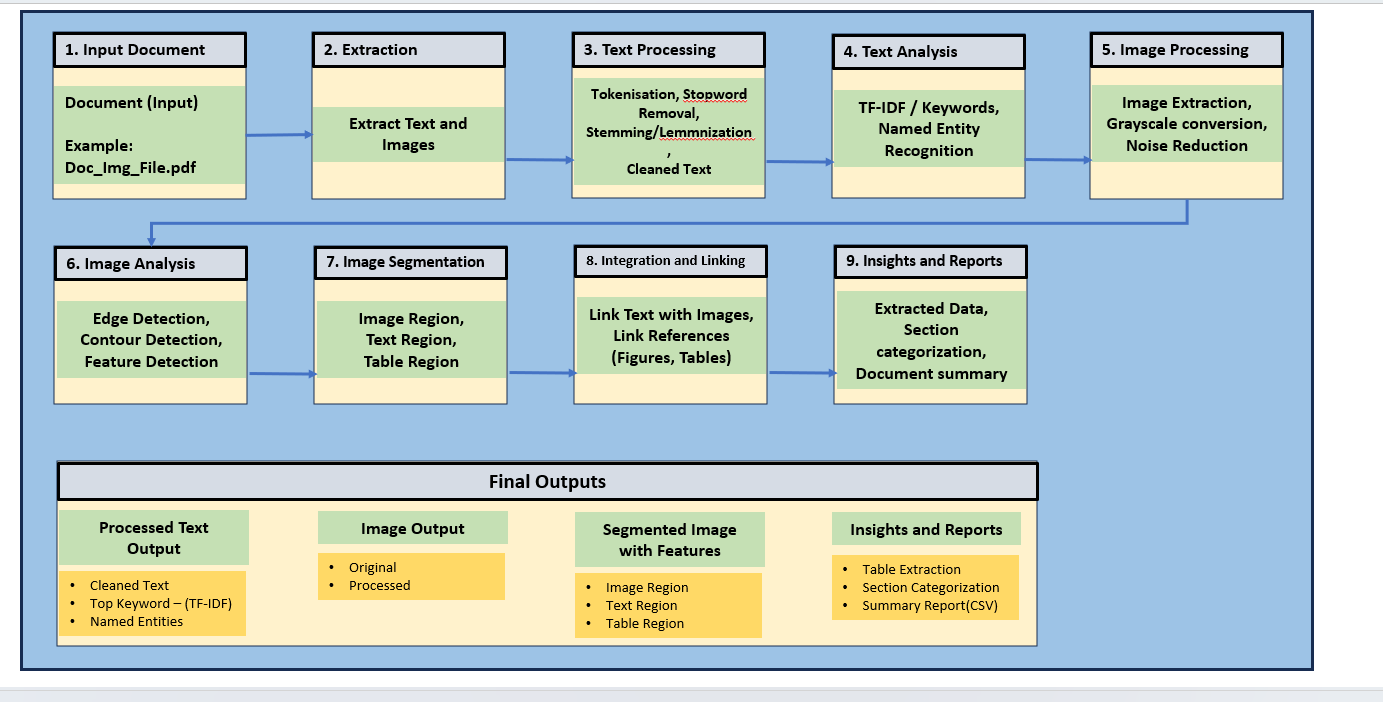

# Initialisation
Perform pip installs(or use a requirements.txt) <br>
perform imports.

**Note: Referred ChatGPT as that helped me in Analysis and Debugging the code**

## Install packages

In [7]:
# pip installs
!pip install PyPDF2
!pip install pdf2image
!pip install rake-nltk
!pip install textblob
!pip install pdfplumber PyPDF2 pandas
!pip install pytesseract pymupdf pillow opencv-python
!pip install opencv-python matplotlib
!pip install pymupdf PyPDF2 pdfplumber opencv-python
!pip install matplotlib nltk scikit-learn spacy pandas pillow

## Imports

In [8]:
# imports
import PyPDF2
import string
import spacy
import pdfplumber
import re
import pandas as pd
import sys
import pymupdf
import os
import site
import cv2
import matplotlib.pyplot as plt
import pytesseract
import fitz
import io
import nltk
from pytesseract import Output
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from PIL import Image
from sklearn.feature_extraction.text import (
    CountVectorizer,
    TfidfVectorizer
)
from textblob import TextBlob
import numpy as np
from collections import Counter
from PyPDF2 import PdfReader

# Support Functions

# NLP

## Text Extraction and Processing

### OCR Text Extraction

In [17]:
# allows inline plotting
%matplotlib inline

# change this path name to where you have stored tesseract.exe
pytesseract.pytesseract.tesseract_cmd = r"C:\Users\Jyoti\tesseract.exe"

In [18]:
# Set Tesseract path manually
pytesseract.pytesseract.tesseract_cmd = (
    r"C:\Users\Jyoti\tesseract.exe"
)

# Open PDF
pdf_path = "Doc_Img_Table_File1.pdf"
doc = fitz.open(pdf_path)

# Store complete OCR text
full_text = ""

# Loop through all PDF pages
for page_num in range(len(doc)):

    # Load page
    page = doc.load_page(page_num)

    # Convert page to image (pixmap)
    pix = page.get_pixmap()

    # Convert pixmap to bytes
    img_bytes = pix.tobytes("png")

    # Open image with PIL
    img = Image.open(io.BytesIO(img_bytes))

    # OCR extraction
    text = pytesseract.image_to_string(img)

    # Store text
    full_text += f"\n--- Page {page_num + 1} ---\n"
    full_text += text

# Print extracted text
print(full_text)

# Save OCR output
with open("ocr_output.txt", "w", encoding="utf-8") as file:
    file.write(full_text)

print("OCR completed successfully!")


--- Page 1 ---
Indian Height-Weight Chart According To Age: A Comprehensive Guide To Health And
Growth
In india, where diverse genetic backsrounds and ifstyes exis, itis essential to understand whats considered

healthy forthe general population. To this end, the Indian helght-weight chart according to age provides an essential
resource fr tracking growth and development at diferent lfe stages and making well-informed lifestyle choices,

Sit bac, relax, and dive into this engaging read that outines the finer points of the indian height-weight chart
according to age, emphasising the various factors that influence our journey towards optimal health and well-being.

Factors Affecting Height And Weight

Genetics play significant role in determining height and weight potential, but nutrition, lifestyle, and physical
activity influence how ths potentials realized. A balanced diet, exercise, and healthy habits impact growth and
‘weight management. Medical conditions or hormonal issues canals

### Text Preprocessing

In [19]:
# ---------------------------------------------------
# OPTIONAL: Set Tesseract path (Windows only)
# ---------------------------------------------------

pytesseract.pytesseract.tesseract_cmd = (
    r"C:\Users\Jyoti\tesseract.exe"
)

# ---------------------------------------------------
# STEP 1: Read PDF and Extract OCR Text
# ---------------------------------------------------

pdf_path = "Doc_Img_Table_File1.pdf"

doc = fitz.open(pdf_path)

full_text = ""

for page_num in range(len(doc)):

    # Load page
    page = doc.load_page(page_num)

    # Convert page to image
    pix = page.get_pixmap()

    # Convert image bytes
    img_bytes = pix.tobytes("png")

    # Open image
    img = Image.open(io.BytesIO(img_bytes))

    # OCR extraction
    text = pytesseract.image_to_string(img)

    # Store text
    full_text += text + " "

# ---------------------------------------------------
# STEP 2: Text Cleaning
# ---------------------------------------------------

# Convert to lowercase
text = full_text.lower()

# Remove special characters and numbers
text = re.sub(r'[^a-zA-Z\s]', '', text)

# Remove extra spaces
text = re.sub(r'\s+', ' ', text).strip()

print("\nCLEANED TEXT:\n")
print(text[:1000])

# ---------------------------------------------------
# STEP 3: Tokenization
# ---------------------------------------------------

tokens = word_tokenize(text)

print("\nTOKENS:\n")
print(tokens[:50])

# ---------------------------------------------------
# STEP 4: Stop Word Removal
# ---------------------------------------------------

stop_words = set(stopwords.words('english'))

filtered_tokens = [
    word for word in tokens
    if word not in stop_words
]

print("\nAFTER STOP WORD REMOVAL:\n")
print(filtered_tokens[:50])

# ---------------------------------------------------
# STEP 5: Stemming
# ---------------------------------------------------

stemmer = PorterStemmer()

stemmed_words = [
    stemmer.stem(word)
    for word in filtered_tokens
]

print("\nSTEMMED WORDS:\n")
print(stemmed_words[:50])

# ---------------------------------------------------
# STEP 6: Lemmatization
# ---------------------------------------------------

lemmatizer = WordNetLemmatizer()

lemmatized_words = [
    lemmatizer.lemmatize(word)
    for word in filtered_tokens
]

print("\nLEMMATIZED WORDS:\n")
print(lemmatized_words[:50])

# ---------------------------------------------------
# STEP 7: Save Outputs
# ---------------------------------------------------

with open("cleaned_text.txt", "w", encoding="utf-8") as f:
    f.write(text)

with open("stemmed_words.txt", "w", encoding="utf-8") as f:
    f.write(" ".join(stemmed_words))

with open("lemmatized_words.txt", "w", encoding="utf-8") as f:
    f.write(" ".join(lemmatized_words))

print("\nText preprocessing completed successfully!")


CLEANED TEXT:

indian heightweight chart according to age a comprehensive guide to health and growth in india where diverse genetic backsrounds and ifstyes exis itis essential to understand whats considered healthy forthe general population to this end the indian helghtweight chart according to age provides an essential resource fr tracking growth and development at diferent lfe stages and making wellinformed lifestyle choices sit bac relax and dive into this engaging read that outines the finer points of the indian heightweight chart according to age emphasising the various factors that influence our journey towards optimal health and wellbeing factors affecting height and weight genetics play significant role in determining height and weight potential but nutrition lifestyle and physical activity influence how ths potentials realized a balanced diet exercise and healthy habits impact growth and weight management medical conditions or hormonal issues canals alect height and weight gr

### Text Feature Extraction

In [20]:
# ---------------------------------------------------
# OPTIONAL: Set Tesseract Path
# ---------------------------------------------------

pytesseract.pytesseract.tesseract_cmd = (
    r"C:\Users\Jyoti\tesseract.exe"
)

# ---------------------------------------------------
# STEP 1: OCR TEXT EXTRACTION
# ---------------------------------------------------

pdf_path = "Doc_Img_Table_File1.pdf"

doc = fitz.open(pdf_path)

full_text = ""

for page_num in range(len(doc)):

    page = doc.load_page(page_num)

    pix = page.get_pixmap()

    img_bytes = pix.tobytes("png")

    img = Image.open(io.BytesIO(img_bytes))

    text = pytesseract.image_to_string(img)

    full_text += text + " "

# ---------------------------------------------------
# STEP 2: TEXT CLEANING
# ---------------------------------------------------

text = full_text.lower()

text = re.sub(r'[^a-zA-Z\s]', '', text)

text = re.sub(r'\s+', ' ', text).strip()

print("\nCLEANED TEXT:\n")
print(text[:1000])

# ---------------------------------------------------
# STEP 3: TOKENIZATION + STOPWORDS
# ---------------------------------------------------

tokens = word_tokenize(text)

stop_words = set(stopwords.words('english'))

filtered_tokens = [
    word for word in tokens
    if word not in stop_words
]

processed_text = " ".join(filtered_tokens)

# ---------------------------------------------------
# STEP 4: BAG OF WORDS (BoW)
# ---------------------------------------------------

print("\n==============================")
print("BAG OF WORDS")
print("==============================")

bow_vectorizer = CountVectorizer()

bow_matrix = bow_vectorizer.fit_transform([processed_text])

bow_features = bow_vectorizer.get_feature_names_out()

print("\nTop BoW Features:\n")
print(bow_features[:50])

# ---------------------------------------------------
# STEP 5: TF-IDF FEATURE EXTRACTION
# ---------------------------------------------------

print("\n==============================")
print("TF-IDF FEATURES")
print("==============================")

tfidf_vectorizer = TfidfVectorizer()

tfidf_matrix = tfidf_vectorizer.fit_transform([processed_text])

feature_names = tfidf_vectorizer.get_feature_names_out()

tfidf_scores = tfidf_matrix.toarray()[0]

# Get top important words
top_indices = tfidf_scores.argsort()[-20:][::-1]

print("\nTop TF-IDF Keywords:\n")

for index in top_indices:
    print(feature_names[index], ":", round(tfidf_scores[index], 4))

# ---------------------------------------------------
# STEP 6: KEY PHRASE EXTRACTION
# ---------------------------------------------------

print("\n==============================")
print("KEY PHRASES")
print("==============================")

phrase_vectorizer = CountVectorizer(
    ngram_range=(2, 3),
    stop_words='english'
)

phrase_matrix = phrase_vectorizer.fit_transform([processed_text])

phrases = phrase_vectorizer.get_feature_names_out()

print("\nTop Key Phrases:\n")

for phrase in phrases[:30]:
    print(phrase)

# ---------------------------------------------------
# STEP 7: NAMED ENTITY RECOGNITION (NER)
# ---------------------------------------------------

print("\n==============================")
print("NAMED ENTITY RECOGNITION")
print("==============================")

# Load spaCy model
nlp = spacy.load("en_core_web_sm")

doc_spacy = nlp(full_text)

print("\nNamed Entities:\n")

for entity in doc_spacy.ents:
    print(entity.text, " --> ", entity.label_)

# ---------------------------------------------------
# STEP 8: SENTIMENT ANALYSIS
# ---------------------------------------------------

print("\n==============================")
print("SENTIMENT ANALYSIS")
print("==============================")

blob = TextBlob(full_text)

sentiment = blob.sentiment

print("\nPolarity:", sentiment.polarity)
print("Subjectivity:", sentiment.subjectivity)

# Interpretation
if sentiment.polarity > 0:
    print("Overall Sentiment: Positive")

elif sentiment.polarity < 0:
    print("Overall Sentiment: Negative")

else:
    print("Overall Sentiment: Neutral")

# ---------------------------------------------------
# STEP 9: SAVE OUTPUTS
# ---------------------------------------------------

with open("processed_text.txt", "w", encoding="utf-8") as f:
    f.write(processed_text)

print("\nNLP Feature Extraction Completed Successfully!")


CLEANED TEXT:

indian heightweight chart according to age a comprehensive guide to health and growth in india where diverse genetic backsrounds and ifstyes exis itis essential to understand whats considered healthy forthe general population to this end the indian helghtweight chart according to age provides an essential resource fr tracking growth and development at diferent lfe stages and making wellinformed lifestyle choices sit bac relax and dive into this engaging read that outines the finer points of the indian heightweight chart according to age emphasising the various factors that influence our journey towards optimal health and wellbeing factors affecting height and weight genetics play significant role in determining height and weight potential but nutrition lifestyle and physical activity influence how ths potentials realized a balanced diet exercise and healthy habits impact growth and weight management medical conditions or hormonal issues canals alect height and weight gr

### Text Analysis

In [21]:
# ---------------------------------------------------
# LOAD SPACY MODEL
# ---------------------------------------------------

nlp = spacy.load("en_core_web_sm")

# ---------------------------------------------------
# PDF FILE PATH
# ---------------------------------------------------

pdf_path = "Doc_Img_Table_File1.pdf"

# ---------------------------------------------------
# STEP 1: SECTION CATEGORIZATION
# ---------------------------------------------------

print("\n==============================")
print("SECTION CATEGORIZATION")
print("==============================")

doc = fitz.open(pdf_path)

titles = []
headings = []
body_text = []
captions = []

for page_num in range(len(doc)):

    page = doc.load_page(page_num)

    blocks = page.get_text("blocks")

    for block in blocks:

        text = block[4].strip()

        if not text:
            continue

        # -----------------------------------------
        # TITLE DETECTION
        # -----------------------------------------

        if len(text.split()) < 12 and text.isupper():

            titles.append(text)

        # -----------------------------------------
        # HEADING DETECTION
        # -----------------------------------------

        elif (
            len(text.split()) < 15
            and text[0].isupper()
        ):

            headings.append(text)

        # -----------------------------------------
        # CAPTION DETECTION
        # -----------------------------------------

        elif re.search(
            r'(figure|fig\.|table)\s*\d+',
            text.lower()
        ):

            captions.append(text)

        # -----------------------------------------
        # BODY TEXT
        # -----------------------------------------

        else:

            body_text.append(text)

# ---------------------------------------------------
# DISPLAY RESULTS
# ---------------------------------------------------

print("\nTITLES:\n")
for t in titles[:10]:
    print("-", t)

print("\nHEADINGS:\n")
for h in headings[:10]:
    print("-", h)

print("\nCAPTIONS:\n")
for c in captions[:10]:
    print("-", c)

print("\nBODY TEXT SAMPLE:\n")
for b in body_text[:5]:
    print("-", b[:200])

# ---------------------------------------------------
# STEP 2: TABLE EXTRACTION
# ---------------------------------------------------

print("\n==============================")
print("TABLE EXTRACTION")
print("==============================")

tables_data = []

with pdfplumber.open(pdf_path) as pdf:

    for page_number, page in enumerate(pdf.pages):

        tables = page.extract_tables()

        for table_num, table in enumerate(tables):

            print(f"\nTable {table_num + 1} on Page {page_number + 1}")

            # Convert to DataFrame
            df = pd.DataFrame(table)

            tables_data.append(df)

            print(df)

            # Save table
            csv_name = (
                f"table_page_"
                f"{page_number+1}_"
                f"{table_num+1}.csv"
            )

            df.to_csv(csv_name, index=False)

# ---------------------------------------------------
# STEP 3: FIGURE/TABLE REFERENCES
# ---------------------------------------------------

print("\n==============================")
print("FIGURE/TABLE REFERENCES")
print("==============================")

full_text = ""

for page in doc:
    full_text += page.get_text()

# Detect references
references = re.findall(
    r'(Figure\s*\d+|Fig\.\s*\d+|Table\s*\d+)',
    full_text,
    flags=re.IGNORECASE
)

unique_refs = list(set(references))

print("\nDetected References:\n")

for ref in unique_refs:
    print(ref)

# ---------------------------------------------------
# STEP 4: RELATIONSHIP BETWEEN TEXT & IMAGES
# ---------------------------------------------------

print("\n==============================")
print("TEXT-IMAGE RELATIONSHIP ANALYSIS")
print("==============================")

for page_num in range(len(doc)):

    page = doc.load_page(page_num)

    images = page.get_images(full=True)

    page_text = page.get_text()

    if images:

        print(
            f"\nPage {page_num + 1} "
            f"contains {len(images)} image(s)."
        )

        # Search references
        refs = re.findall(
            r'(Figure\s*\d+|Fig\.\s*\d+|Table\s*\d+)',
            page_text,
            flags=re.IGNORECASE
        )

        if refs:

            print("Related References Found:")

            for r in refs:
                print("-", r)

        else:

            print(
                "No figure/table references "
                "found on this page."
            )

# ---------------------------------------------------
# STEP 5: NAMED ENTITY ANALYSIS
# ---------------------------------------------------

print("\n==============================")
print("NAMED ENTITY ANALYSIS")
print("==============================")

doc_spacy = nlp(full_text)

for ent in doc_spacy.ents[:50]:

    print(ent.text, " --> ", ent.label_)

# ---------------------------------------------------
# STEP 6: SAVE SECTION OUTPUTS
# ---------------------------------------------------

with open("titles.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(titles))

with open("headings.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(headings))

with open("captions.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(captions))

with open("body_text.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(body_text))

print("\nDocument Analysis Completed Successfully!")


SECTION CATEGORIZATION

TITLES:


HEADINGS:

- Indian Height-Weight Chart According To Age: A Comprehensive Guide To Health And 
Growth
- Factors Affecting Height And Weight
- Growth And Development In Different Age Groups
- Adults’ Average Height And Weight Chart By Age In India
- An approximate height-weight ratio chart for adult women:
- Height 
Weight
- An approximate height-weight ratio chart for adult men:
- Height 
Weight
- Children’s Average Height And Weight Chart By Age In India
- Age 
Weight 
Length

CAPTIONS:


BODY TEXT SAMPLE:

- In India, where diverse genetic backgrounds and lifestyles exist, it is essential to understand what is considered 
healthy for the general population. To this end, the Indian height-weight chart acco
- Genetics play a significant role in determining height and weight potential, but nutrition, lifestyle, and physical 
activity influence how this potential is realized. A balanced diet, exercise, and h
- Growth rates vary among age groups. Infants

# Vision

## Image Processing and Feature Detection

### Image Preprocessing

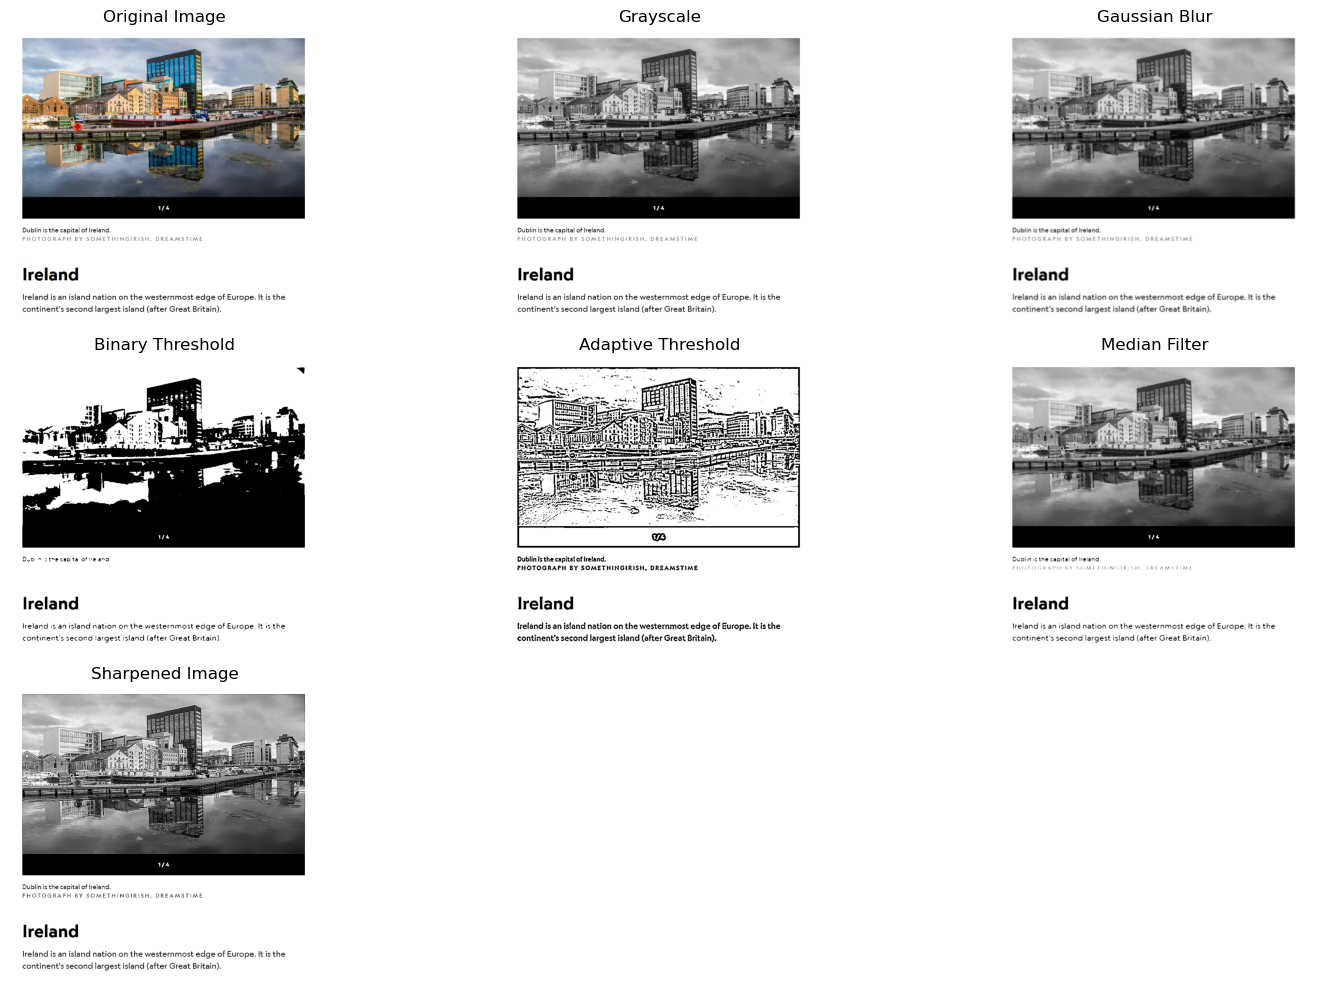

Processed images saved successfully.


In [27]:
# -----------------------------
# Step 1: Load Image
# -----------------------------
image_path = "IMG_Doc.png"

# Read image
img = cv2.imread(image_path)

# Convert BGR to RGB (for displaying correctly in matplotlib)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# -----------------------------
# Step 2: Convert to Grayscale
# -----------------------------
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# -----------------------------
# Step 3: Noise Reduction
# -----------------------------
# Gaussian Blur helps reduce image noise
blur = cv2.GaussianBlur(gray, (5, 5), 0)

# -----------------------------
# Step 4: Thresholding
# -----------------------------
# Binary Threshold
_, thresh = cv2.threshold(
    blur,
    127,
    255,
    cv2.THRESH_BINARY
)

# Adaptive Thresholding (better for documents)
adaptive_thresh = cv2.adaptiveThreshold(
    blur,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11,
    2
)

# -----------------------------
# Step 5: Median Filtering
# -----------------------------
# Removes salt-and-pepper noise
median = cv2.medianBlur(gray, 3)

# -----------------------------
# Step 6: Sharpening
# -----------------------------
kernel = [[0, -1, 0],
          [-1, 5, -1],
          [0, -1, 0]]

kernel = np.array(kernel)

sharpened = cv2.filter2D(gray, -1, kernel)

# -----------------------------
# Step 7: Display Results
# -----------------------------
titles = [
    "Original Image",
    "Grayscale",
    "Gaussian Blur",
    "Binary Threshold",
    "Adaptive Threshold",
    "Median Filter",
    "Sharpened Image"
]

images = [
    img_rgb,
    gray,
    blur,
    thresh,
    adaptive_thresh,
    median,
    sharpened
]

plt.figure(figsize=(15, 10))

for i in range(len(images)):
    plt.subplot(3, 3, i + 1)

    # Use grayscale colormap for processed images
    if len(images[i].shape) == 2:
        plt.imshow(images[i], cmap='gray')
    else:
        plt.imshow(images[i])

    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

print("Processed images saved successfully.")

### Feature Detection

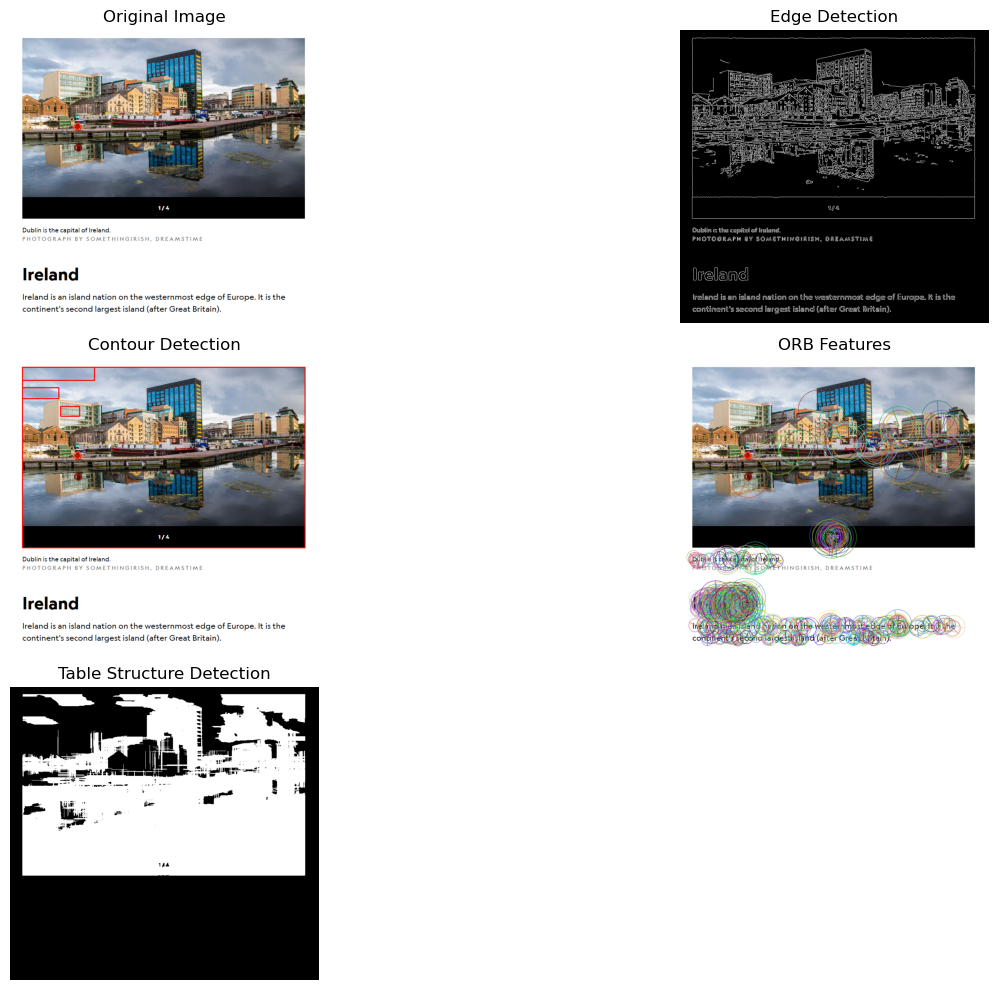

=== Detected Regions ===
Region 1: x=143, y=134, width=54, height=28
Region 2: x=35, y=81, width=103, height=31
Region 3: x=35, y=23, width=801, height=512
Region 4: x=35, y=23, width=204, height=37

Total Regions Detected: 4

Processed feature images saved successfully.


In [28]:
# -----------------------------
# Step 1: Load Image
# -----------------------------
image_path = "IMG_Doc.png"

img = cv2.imread(image_path)

# Convert to RGB for display
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# -----------------------------
# Step 2: Edge Detection (Canny)
# -----------------------------
edges = cv2.Canny(gray, 100, 200)

# -----------------------------
# Step 3: Thresholding
# -----------------------------
_, thresh = cv2.threshold(
    gray,
    180,
    255,
    cv2.THRESH_BINARY_INV
)

# -----------------------------
# Step 4: Contour Detection
# Detect text blocks, tables, images
# -----------------------------
contours, hierarchy = cv2.findContours(
    thresh,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# Create copy for drawing
contour_img = img_rgb.copy()

detected_regions = []

for cnt in contours:

    x, y, w, h = cv2.boundingRect(cnt)

    # Filter very small regions
    if w > 50 and h > 20:

        detected_regions.append((x, y, w, h))

        # Draw bounding box
        cv2.rectangle(
            contour_img,
            (x, y),
            (x + w, y + h),
            (255, 0, 0),
            2
        )

# -----------------------------
# Step 5: ORB Feature Detection
# -----------------------------
orb = cv2.ORB_create(nfeatures=500)

keypoints, descriptors = orb.detectAndCompute(gray, None)

orb_img = cv2.drawKeypoints(
    img_rgb,
    keypoints,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

# -----------------------------
# Step 6: Detect Horizontal & Vertical Lines
# Useful for tables
# -----------------------------
horizontal_kernel = cv2.getStructuringElement(
    cv2.MORPH_RECT,
    (40, 1)
)

vertical_kernel = cv2.getStructuringElement(
    cv2.MORPH_RECT,
    (1, 40)
)

horizontal_lines = cv2.morphologyEx(
    thresh,
    cv2.MORPH_OPEN,
    horizontal_kernel
)

vertical_lines = cv2.morphologyEx(
    thresh,
    cv2.MORPH_OPEN,
    vertical_kernel
)

table_structure = cv2.add(horizontal_lines, vertical_lines)

# -----------------------------
# Step 7: Display Results
# -----------------------------
titles = [
    "Original Image",
    "Edge Detection",
    "Contour Detection",
    "ORB Features",
    "Table Structure Detection"
]

images = [
    img_rgb,
    edges,
    contour_img,
    orb_img,
    table_structure
]

plt.figure(figsize=(15, 10))

for i in range(len(images)):

    plt.subplot(3, 2, i + 1)

    if len(images[i].shape) == 2:
        plt.imshow(images[i], cmap='gray')
    else:
        plt.imshow(images[i])

    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

# -----------------------------
# Step 8: Print Detected Regions
# -----------------------------
print("=== Detected Regions ===")

for i, region in enumerate(detected_regions[:20]):
    x, y, w, h = region
    print(f"Region {i+1}: x={x}, y={y}, width={w}, height={h}")

print("\nTotal Regions Detected:", len(detected_regions))

print("\nProcessed feature images saved successfully.")

### Image Segmentation

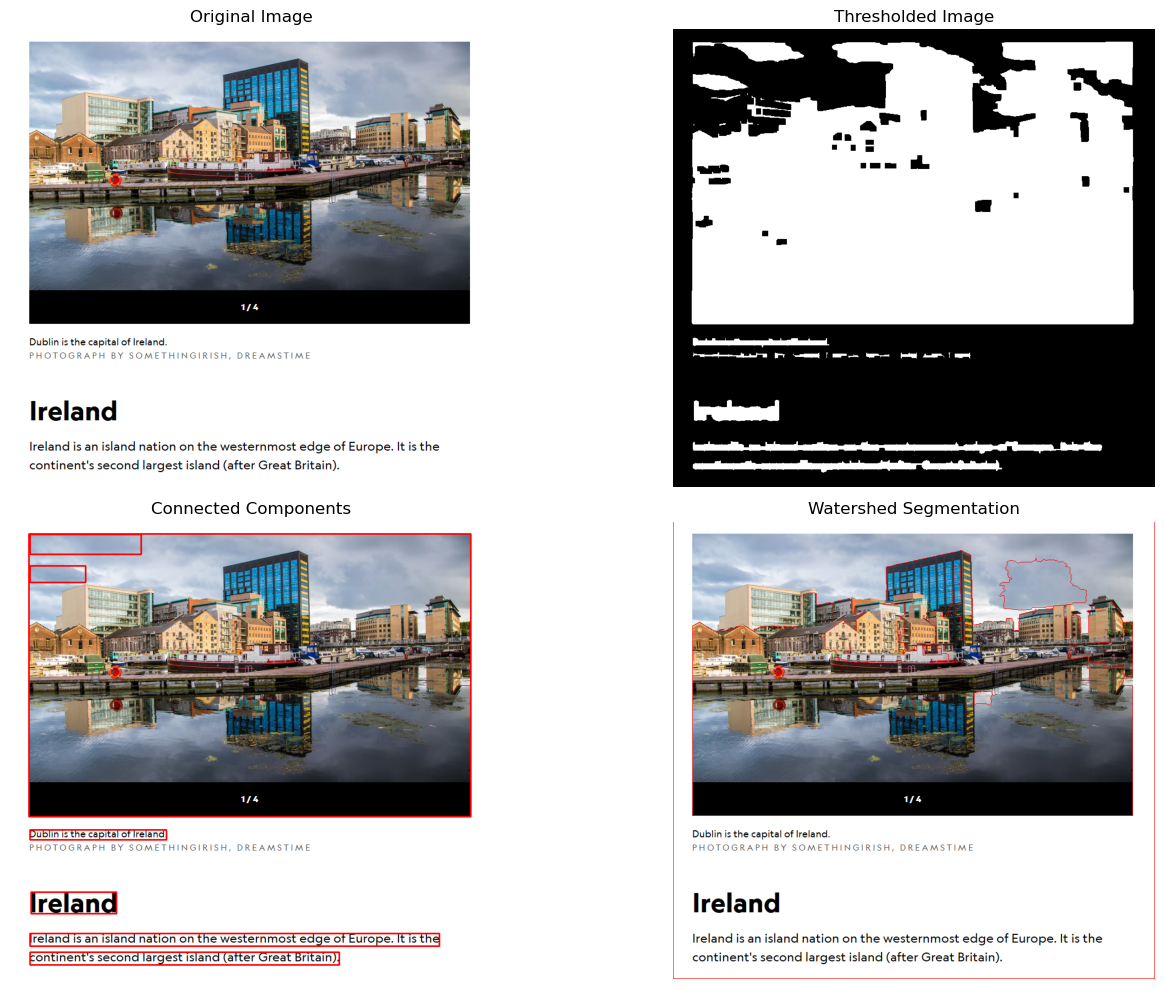

=== TEXT REGIONS ===
Text Region 1: x=36, y=24, w=202, h=36, area=3627
Text Region 2: x=36, y=81, w=101, h=30, area=2004
Text Region 3: x=36, y=560, w=248, h=18, area=2432
Text Region 4: x=38, y=673, w=155, h=39, area=4056
Text Region 5: x=36, y=748, w=744, h=23, area=8414
Text Region 6: x=36, y=782, w=562, h=23, area=6788

=== IMAGE/DIAGRAM REGIONS ===
Image Region 1: x=34, y=23, w=803, h=513, area=341534

Total Regions Detected: 7

Segmented images saved successfully.


In [29]:
# -----------------------------
# Step 1: Load Image
# -----------------------------
image_path = "IMG_Doc.png"

img = cv2.imread(image_path)

# Convert BGR to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert to Grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# -----------------------------
# Step 2: Noise Reduction
# -----------------------------
blur = cv2.GaussianBlur(gray, (5, 5), 0)

# -----------------------------
# Step 3: Binary Thresholding
# -----------------------------
_, thresh = cv2.threshold(
    blur,
    180,
    255,
    cv2.THRESH_BINARY_INV
)

# -----------------------------
# Step 4: Morphological Operations
# Helps connect text regions
# -----------------------------
kernel = cv2.getStructuringElement(
    cv2.MORPH_RECT,
    (5, 5)
)

morph = cv2.morphologyEx(
    thresh,
    cv2.MORPH_CLOSE,
    kernel,
    iterations=2
)

# -----------------------------
# Step 5: Connected Components
# Segment meaningful regions
# -----------------------------
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
    morph,
    connectivity=8
)

# Create image for visualization
segmented_img = img_rgb.copy()

regions = []

for i in range(1, num_labels):  # skip background

    x = stats[i, cv2.CC_STAT_LEFT]
    y = stats[i, cv2.CC_STAT_TOP]
    w = stats[i, cv2.CC_STAT_WIDTH]
    h = stats[i, cv2.CC_STAT_HEIGHT]
    area = stats[i, cv2.CC_STAT_AREA]

    # Filter tiny regions
    if area > 1000:

        regions.append((x, y, w, h, area))

        # Draw bounding box
        cv2.rectangle(
            segmented_img,
            (x, y),
            (x + w, y + h),
            (255, 0, 0),
            2
        )

# -----------------------------
# Step 6: Watershed Segmentation
# -----------------------------
# Sure background
sure_bg = cv2.dilate(morph, kernel, iterations=3)

# Distance transform
dist_transform = cv2.distanceTransform(
    morph,
    cv2.DIST_L2,
    5
)

# Sure foreground
_, sure_fg = cv2.threshold(
    dist_transform,
    0.3 * dist_transform.max(),
    255,
    0
)

sure_fg = np.uint8(sure_fg)

# Unknown region
unknown = cv2.subtract(sure_bg, sure_fg)

# Marker labeling
_, markers = cv2.connectedComponents(sure_fg)

markers = markers + 1
markers[unknown == 255] = 0

# Apply watershed
watershed_img = img.copy()

markers = cv2.watershed(watershed_img, markers)

# Mark boundaries in red
watershed_img[markers == -1] = [0, 0, 255]

watershed_rgb = cv2.cvtColor(watershed_img, cv2.COLOR_BGR2RGB)

# -----------------------------
# Step 7: Region Classification
# Simple heuristic-based grouping
# -----------------------------
text_regions = []
image_regions = []

for region in regions:

    x, y, w, h, area = region

    aspect_ratio = w / h

    # Heuristic:
    # Wide regions likely text blocks
    # Large square regions likely images

    if aspect_ratio > 2:
        text_regions.append(region)
    else:
        image_regions.append(region)

# -----------------------------
# Step 8: Display Results
# -----------------------------
titles = [
    "Original Image",
    "Thresholded Image",
    "Connected Components",
    "Watershed Segmentation"
]

images = [
    img_rgb,
    morph,
    segmented_img,
    watershed_rgb
]

plt.figure(figsize=(15, 10))

for i in range(len(images)):

    plt.subplot(2, 2, i + 1)

    if len(images[i].shape) == 2:
        plt.imshow(images[i], cmap='gray')
    else:
        plt.imshow(images[i])

    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

# -----------------------------
# Step 9: Print Region Information
# -----------------------------
print("=== TEXT REGIONS ===")

for i, region in enumerate(text_regions[:10]):
    x, y, w, h, area = region
    print(f"Text Region {i+1}: x={x}, y={y}, w={w}, h={h}, area={area}")

print("\n=== IMAGE/DIAGRAM REGIONS ===")

for i, region in enumerate(image_regions[:10]):
    x, y, w, h, area = region
    print(f"Image Region {i+1}: x={x}, y={y}, w={w}, h={h}, area={area}")

print("\nTotal Regions Detected:", len(regions))

print("\nSegmented images saved successfully.")

### Image Enhancement

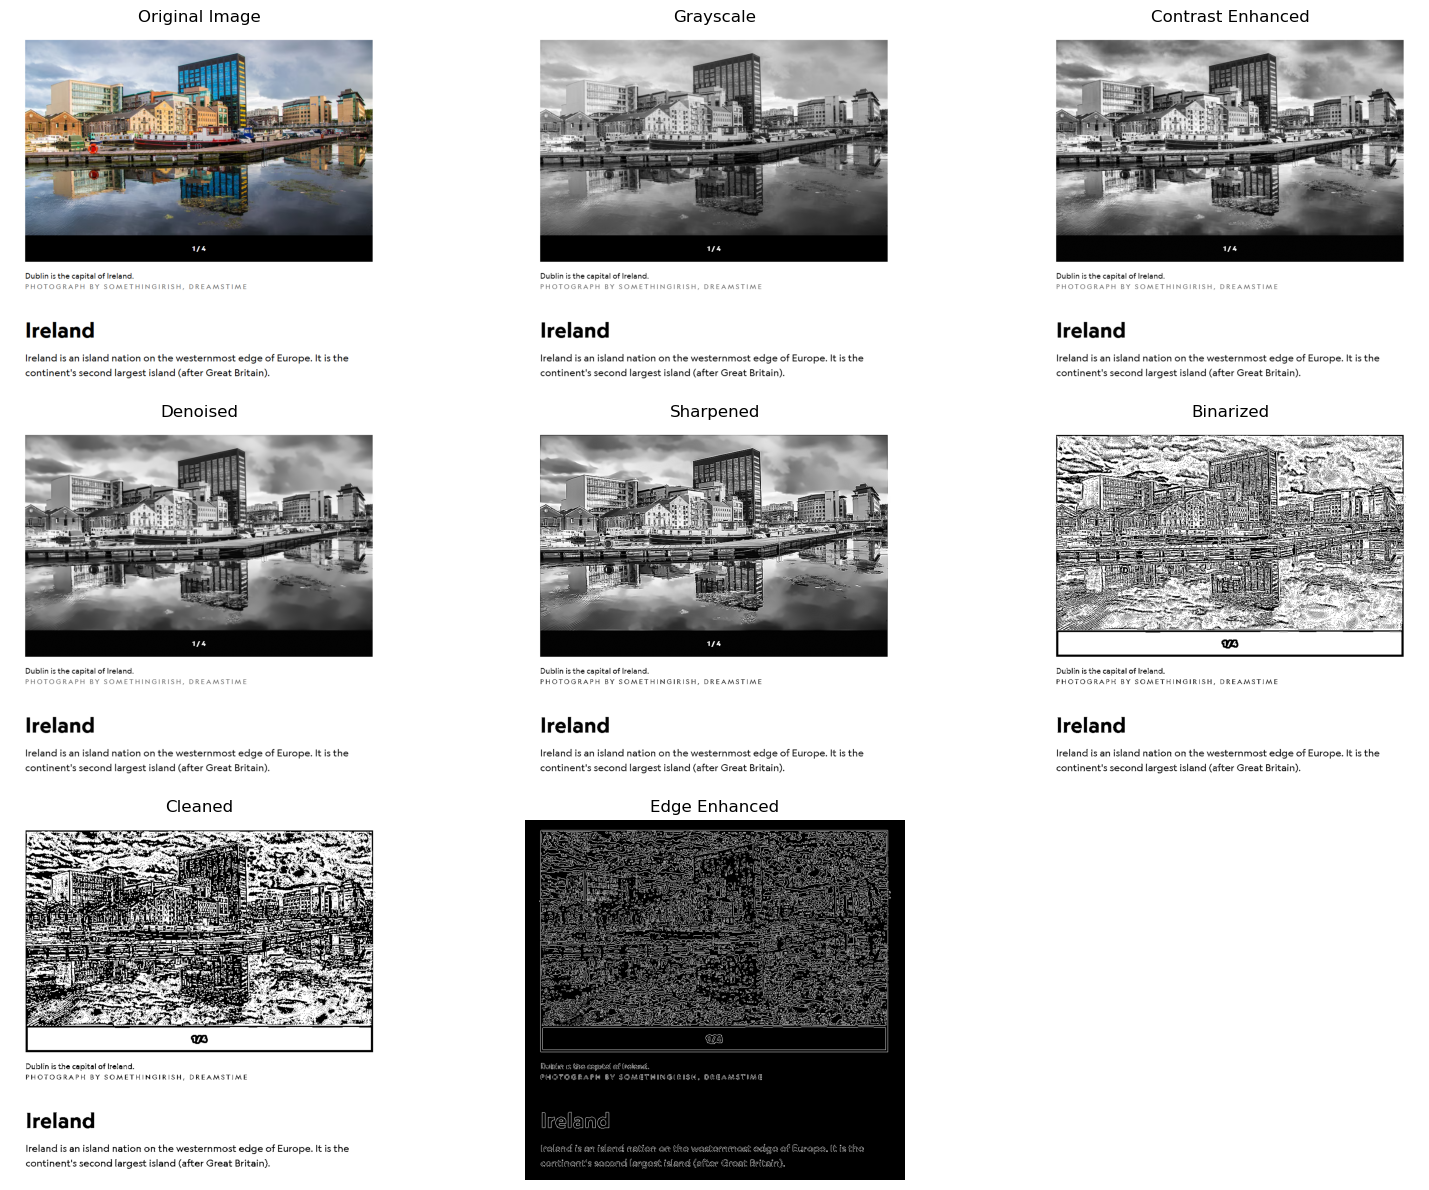

OCR-ready image saved as 'ocr_ready_image.png'


In [31]:
# -----------------------------
# Step 1: Load Image
# -----------------------------
image_path = "IMG_Doc.png"

img = cv2.imread(image_path)

# Convert BGR to RGB for display
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert to Grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# -----------------------------
# Step 2: Contrast Enhancement
# CLAHE (Adaptive Histogram Equalization)
# -----------------------------
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)

contrast_enhanced = clahe.apply(gray)

# -----------------------------
# Step 3: Noise Reduction
# -----------------------------
denoised = cv2.fastNlMeansDenoising(
    contrast_enhanced,
    None,
    h=10,
    templateWindowSize=7,
    searchWindowSize=21
)

# -----------------------------
# Step 4: Deblurring / Sharpening
# -----------------------------
sharpen_kernel = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

sharpened = cv2.filter2D(
    denoised,
    -1,
    sharpen_kernel
)

# -----------------------------
# Step 5: Binarization
# Adaptive Thresholding
# -----------------------------
binary = cv2.adaptiveThreshold(
    sharpened,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11,
    2
)

# -----------------------------
# Step 6: Morphological Cleanup
# Remove tiny noise
# -----------------------------
kernel = cv2.getStructuringElement(
    cv2.MORPH_RECT,
    (2, 2)
)

cleaned = cv2.morphologyEx(
    binary,
    cv2.MORPH_OPEN,
    kernel
)

# -----------------------------
# Step 7: Edge Enhancement
# -----------------------------
edges = cv2.Canny(cleaned, 50, 150)

# -----------------------------
# Step 8: Display Results
# -----------------------------
titles = [
    "Original Image",
    "Grayscale",
    "Contrast Enhanced",
    "Denoised",
    "Sharpened",
    "Binarized",
    "Cleaned",
    "Edge Enhanced"
]

images = [
    img_rgb,
    gray,
    contrast_enhanced,
    denoised,
    sharpened,
    binary,
    cleaned,
    edges
]

plt.figure(figsize=(16, 12))

for i in range(len(images)):

    plt.subplot(3, 3, i + 1)

    if len(images[i].shape) == 2:
        plt.imshow(images[i], cmap='gray')
    else:
        plt.imshow(images[i])

    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

# -----------------------------
# Step 10: OCR-Ready Output
# Best image for OCR
# -----------------------------
cv2.imwrite("ocr_ready_image.png", cleaned)

print("OCR-ready image saved as 'ocr_ready_image.png'")

# Multi-modal

## Text and Image Integration

In [21]:
# Install Spacy
!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ----- ---------------------------------- 1.8/12.8 MB 10.1 MB/s eta 0:00:02
     ------------------ --------------------- 5.8/12.8 MB 15.3 MB/s eta 0:00:01
     ------------------------------- ------- 10.2/12.8 MB 17.7 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 17.1 MB/s  0:00:00
[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Jyoti\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Jyoti\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Jyoti\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


=== TEXT PREVIEW ===

Indian Height -Weight Chart According To Age: A Comprehensive Guide To Health And 
Growth  
In India, where diverse genetic backgrounds and lifestyles exist, it is essential to understand what is considered 
healthy for the general population. To this end, the Indian height -weight chart according to age provides an essential 
resource for tracking growth and development at different life stages and making well -informed lifestyle choices.  
 
Sit back, relax, and dive into this engaging read that outlines the finer points of the Indian height -weight chart 
according to age, emphasising the various factor s that influence our journey towards optimal health and well -being.  
 
Factors Affecting Height And Weight  
Genetics play a significant role in determining height and weight potential, but nutrition, lifestyle, and physical 
activity influence how this potential is realized. A balanced diet, exercise, and healthy habits impact growth and 
weight management. M

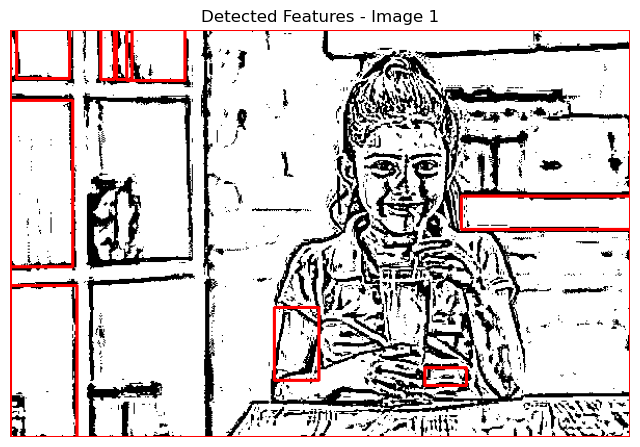


=== FEATURES IN IMAGE 2 ===
Region 1: x=418, y=210, w=62, h=68
Region 2: x=222, y=170, w=40, h=27
Region 3: x=256, y=123, w=42, h=54
Region 4: x=300, y=110, w=26, h=27
Region 5: x=151, y=91, w=47, h=22
Region 6: x=288, y=34, w=41, h=50
Region 7: x=161, y=31, w=168, h=190
Region 8: x=143, y=28, w=69, h=73
Region 9: x=0, y=0, w=480, h=320


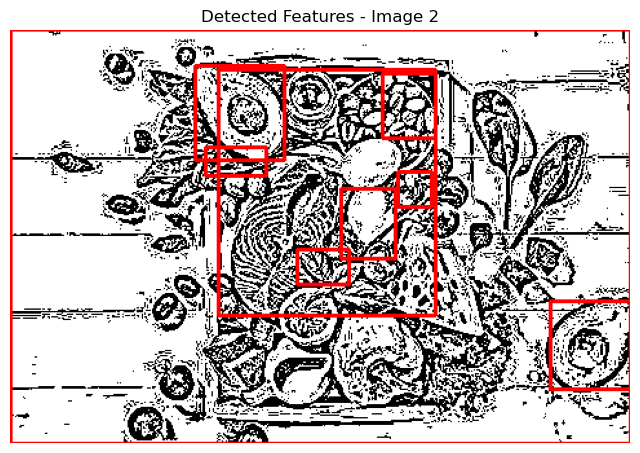


=== FEATURES IN IMAGE 3 ===
Region 1: x=0, y=0, w=480, h=480


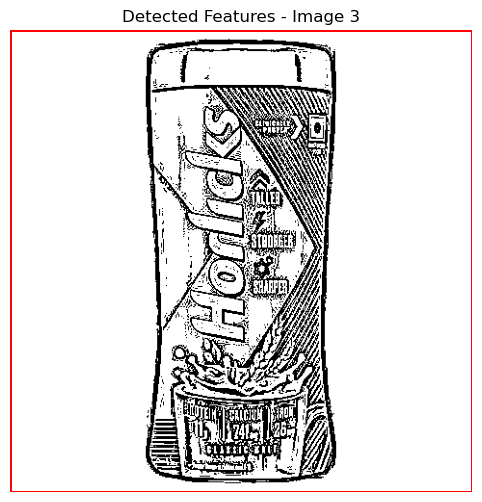


=== REFERENCES FOUND ===
set()

=== UNIFIED DOCUMENT UNDERSTANDING ===

Total Words:
518

Top Keywords:
['age', 'approximate', 'bmi', 'body', 'chart', 'children', 'cm', 'different', 'essential', 'frame']

Named Entities:
['Adults', 'Average Height And Weight Chart By Age In India  \nUnderstanding', 'Age Weight  Length', 'Please', 'Categorised', 'Considered', 'Comprehensive Guide To Health And \nGrowth  \nIn India', 'Children', 'Growing With Horlicks  \nHorlicks', 'Its']

Sentiment:
{'neg': 0.009, 'neu': 0.857, 'pos': 0.133, 'compound': 0.9989}

Extracted Images:
3

Detected References:
[]

Document summary saved as document_summary.csv


In [24]:
# =========================================================
# DOWNLOAD NLTK RESOURCES
# =========================================================
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')

# =========================================================
# FILE PATH
# =========================================================
pdf_path = "Doc_Img_Table_File1.pdf"

# =========================================================
# STEP 1: EXTRACT TEXT FROM PDF
# =========================================================
reader = PdfReader(pdf_path)

full_text = ""

for page in reader.pages:
    full_text += page.extract_text() or ""

print("=== TEXT PREVIEW ===\n")
print(full_text[:1000])

# =========================================================
# STEP 2: TEXT PREPROCESSING
# =========================================================
tokens = word_tokenize(full_text)

stop_words = set(stopwords.words('english'))

clean_tokens = [
    word.lower()
    for word in tokens
    if word.lower() not in stop_words
    and word not in string.punctuation
    and word.isalpha()
]

clean_text = " ".join(clean_tokens)

print("\n=== CLEAN TOKENS ===")
print(clean_tokens[:50])

# =========================================================
# STEP 3: TF-IDF FEATURE EXTRACTION
# =========================================================
tfidf = TfidfVectorizer(max_features=20)

tfidf_matrix = tfidf.fit_transform([clean_text])

keywords = tfidf.get_feature_names_out()

print("\n=== TF-IDF KEYWORDS ===")
print(keywords)

# =========================================================
# STEP 4: SIMPLE NAMED ENTITY EXTRACTION
# Capitalized word sequences
# =========================================================
entity_pattern = r'\b[A-Z][a-z]+(?:\s+[A-Z][a-z]+)*\b'

entities = re.findall(entity_pattern, full_text)

# Remove duplicates
entities = list(set(entities))

print("\n=== SIMPLE NAMED ENTITIES ===")
print(entities[:20])

# =========================================================
# STEP 5: SENTIMENT ANALYSIS
# =========================================================
sia = SentimentIntensityAnalyzer()

sentiment = sia.polarity_scores(full_text)

print("\n=== SENTIMENT ANALYSIS ===")
print(sentiment)

# =========================================================
# STEP 6: EXTRACT IMAGES FROM PDF
# =========================================================
pdf_document = fitz.open(pdf_path)

image_info = []

for page_index in range(len(pdf_document)):

    page = pdf_document[page_index]

    image_list = page.get_images(full=True)

    for img_index, img in enumerate(image_list):

        xref = img[0]

        base_image = pdf_document.extract_image(xref)

        image_bytes = base_image["image"]

        image_ext = base_image["ext"]

        image_name = f"page{page_index+1}_img{img_index+1}.{image_ext}"

        with open(image_name, "wb") as f:
            f.write(image_bytes)

        image_info.append(image_name)

print("\n=== EXTRACTED IMAGES ===")
print(image_info)

# =========================================================
# STEP 7: IMAGE PROCESSING
# =========================================================
processed_images = []

for image_path in image_info:

    img = cv2.imread(image_path)

    if img is None:
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Contrast enhancement
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    enhanced = clahe.apply(gray)

    # Denoising
    denoised = cv2.fastNlMeansDenoising(enhanced)

    # Adaptive thresholding
    binary = cv2.adaptiveThreshold(
        denoised,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        11,
        2
    )

    processed_images.append(binary)

print("\n=== IMAGE PREPROCESSING COMPLETE ===")

# =========================================================
# STEP 8: FEATURE DETECTION
# =========================================================
for idx, img in enumerate(processed_images):

    contours, _ = cv2.findContours(
        img,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    contour_img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

    print(f"\n=== FEATURES IN IMAGE {idx+1} ===")

    region_count = 0

    for cnt in contours:

        x, y, w, h = cv2.boundingRect(cnt)

        area = w * h

        if area > 500:

            region_count += 1

            cv2.rectangle(
                contour_img,
                (x, y),
                (x+w, y+h),
                (255, 0, 0),
                2
            )

            print(f"Region {region_count}: "
                  f"x={x}, y={y}, w={w}, h={h}")

    plt.figure(figsize=(8,6))
    plt.imshow(contour_img)
    plt.title(f"Detected Features - Image {idx+1}")
    plt.axis("off")
    plt.show()

# =========================================================
# STEP 9: DETECT FIGURE/TABLE REFERENCES
# =========================================================
reference_patterns = r'(Figure\s*\d+|Fig\.\s*\d+|Table\s*\d+)'

references = re.findall(
    reference_patterns,
    full_text,
    re.IGNORECASE
)

print("\n=== REFERENCES FOUND ===")
print(set(references))

# =========================================================
# STEP 10: UNIFIED DOCUMENT UNDERSTANDING
# =========================================================
document_summary = {
    "Total Words": len(clean_tokens),
    "Top Keywords": list(keywords[:10]),
    "Named Entities": entities[:10],
    "Sentiment": sentiment,
    "Extracted Images": len(image_info),
    "Detected References": list(set(references))
}

print("\n=== UNIFIED DOCUMENT UNDERSTANDING ===")

for key, value in document_summary.items():
    print(f"\n{key}:")
    print(value)

# =========================================================
# STEP 11: SAVE SUMMARY
# =========================================================
summary_df = pd.DataFrame({
    "Category": list(document_summary.keys()),
    "Details": [str(v) for v in document_summary.values()]
})

summary_df.to_csv("document_summary.csv", index=False)

print("\nDocument summary saved as document_summary.csv")

# Final Output

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Jyoti\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Jyoti\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Jyoti\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


=== RAW TEXT PREVIEW ===
Indian Height -Weight Chart According To Age: A Comprehensive Guide To Health And 
Growth  
In India, where diverse genetic backgrounds and lifestyles exist, it is essential to understand what is considered 
healthy for the general population. To this end, the Indian height -weight chart according to age provides an essential 
resource for tracking growth and development at different life stages and making well -informed lifestyle choices.  
 
Sit back, relax, and dive into this engaging read that outlines the finer points of the Indian height -weight chart 
according to age, emphasising the various factor s that influence our journey towards optimal health and well -being.  
 
Factors Affecting Height And Weight  
Genetics play a significant role in determining height and weight potential, but nutrition, lifestyle, and physical 
activity influence how this potential is realized. A balanced diet, exercise, and healthy habits impact growth and 
weight management

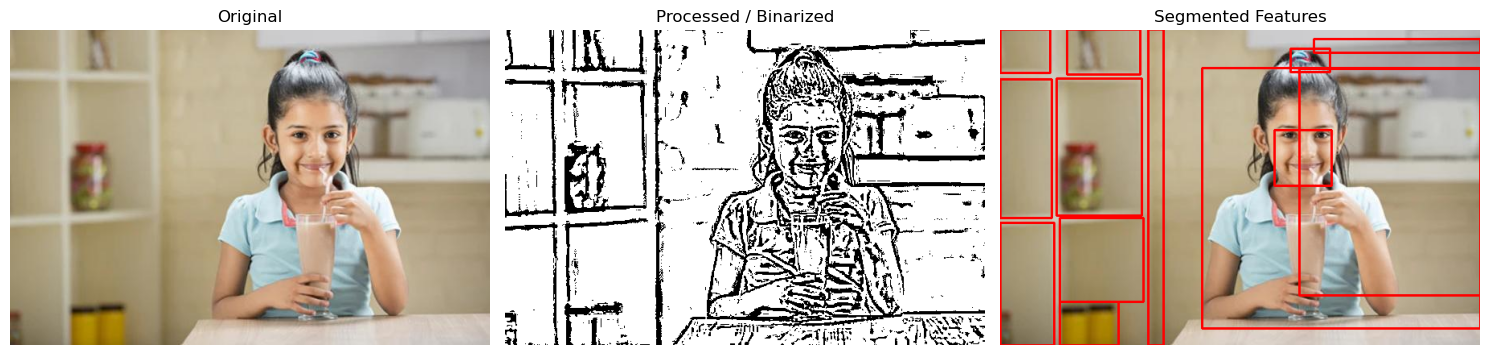


Detected Regions in Image 1:
(np.int32(0), np.int32(0), np.int32(62), np.int32(54))
(np.int32(83), np.int32(0), np.int32(91), np.int32(56))
(np.int32(184), np.int32(0), np.int32(19), np.int32(392))
(np.int32(390), np.int32(12), np.int32(207), np.int32(17))
(np.int32(361), np.int32(24), np.int32(49), np.int32(29))
(np.int32(251), np.int32(48), np.int32(346), np.int32(323))
(np.int32(372), np.int32(49), np.int32(225), np.int32(281))
(np.int32(70), np.int32(61), np.int32(106), np.int32(170))
(np.int32(0), np.int32(62), np.int32(64), np.int32(172))
(np.int32(341), np.int32(125), np.int32(71), np.int32(69))


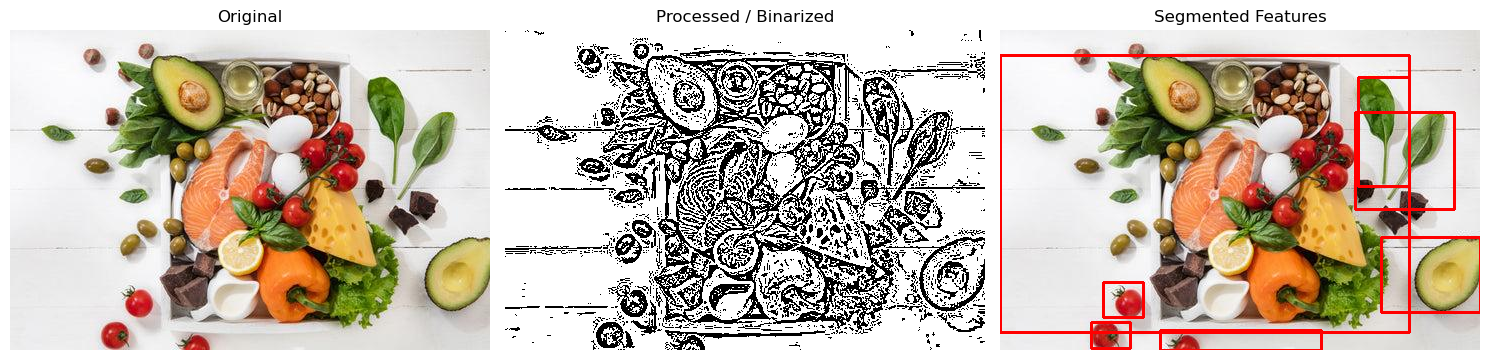


Detected Regions in Image 2:
(np.int32(0), np.int32(25), np.int32(409), np.int32(277))
(np.int32(358), np.int32(47), np.int32(51), np.int32(109))
(np.int32(355), np.int32(82), np.int32(99), np.int32(97))
(np.int32(381), np.int32(207), np.int32(99), np.int32(75))
(np.int32(103), np.int32(252), np.int32(40), np.int32(35))
(np.int32(91), np.int32(292), np.int32(39), np.int32(26))
(np.int32(160), np.int32(300), np.int32(161), np.int32(20))


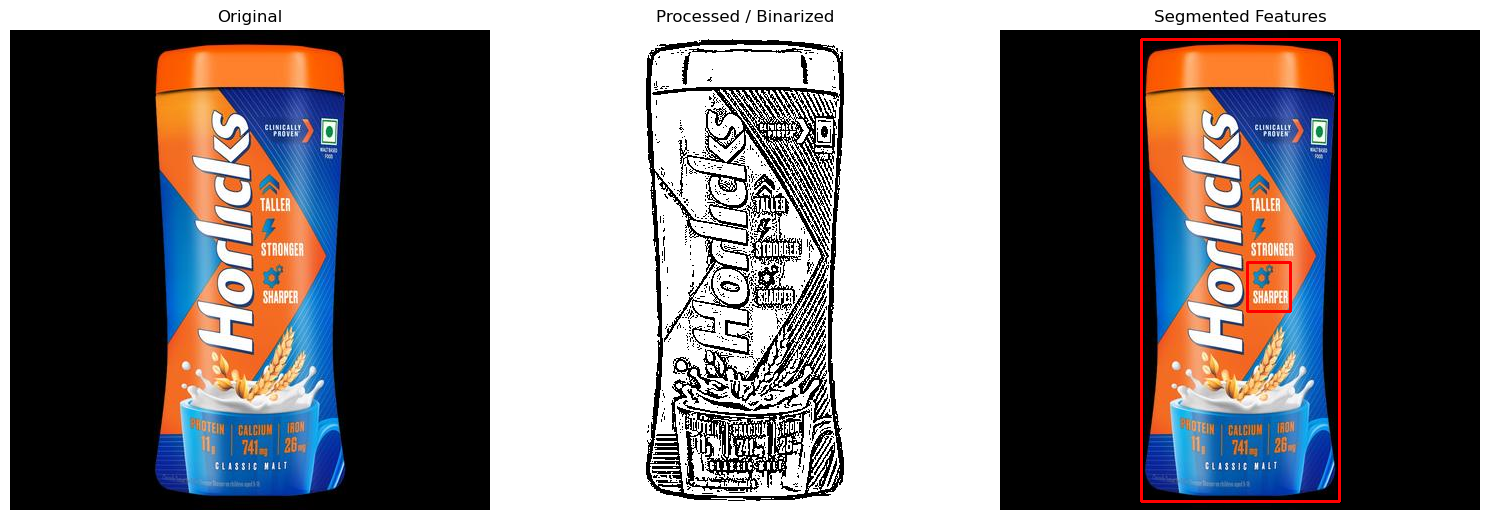


Detected Regions in Image 3:
(np.int32(141), np.int32(9), np.int32(198), np.int32(462))
(np.int32(247), np.int32(232), np.int32(43), np.int32(49))

=== REFERENCES DETECTED ===
set()

=== FINAL DOCUMENT SUMMARY ===

Total Words:
518

Top Keywords:
['age', 'approximate', 'bmi', 'body', 'chart', 'children', 'cm', 'different', 'essential', 'frame']

Named Entities:
['Adults', 'Average Height And Weight Chart By Age In India  \nUnderstanding', 'Age Weight  Length', 'Please', 'Categorised', 'Considered', 'Comprehensive Guide To Health And \nGrowth  \nIn India', 'Children', 'Growing With Horlicks  \nHorlicks', 'Its']

Sentiment:
{'neg': 0.009, 'neu': 0.857, 'pos': 0.133, 'compound': 0.9989}

Titles:
['Indian Height -Weight Chart According To Age: A Comprehensive Guide To Health And', 'Growth And Development In Different Age Groups', 'Adults’ Average Height And Weight Chart By Age In India']

Captions:
[]

Tables Extracted:
4

Images Extracted:
3

References:
[]

Final report saved as final_d

In [32]:
# Final Integrated Document Understanding Pipeline
# =========================================================
# DOWNLOAD NLTK RESOURCES
# =========================================================
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')

# =========================================================
# FILE PATH
# =========================================================
pdf_path = "Doc_Img_Table_File1.pdf"

# =========================================================
# STEP 1: TEXT EXTRACTION
# =========================================================
reader = PdfReader(pdf_path)

full_text = ""

for page in reader.pages:
    full_text += page.extract_text() or ""

print("=== RAW TEXT PREVIEW ===")
print(full_text[:1000])

# =========================================================
# STEP 2: TEXT PREPROCESSING
# =========================================================
tokens = word_tokenize(full_text)

stop_words = set(stopwords.words('english'))

clean_tokens = [
    word.lower()
    for word in tokens
    if word.lower() not in stop_words
    and word not in string.punctuation
    and word.isalpha()
]

clean_text = " ".join(clean_tokens)

print("\n=== CLEANED TEXT ===")
print(clean_text[:1000])

# =========================================================
# STEP 3: TF-IDF FEATURE EXTRACTION
# =========================================================
tfidf = TfidfVectorizer(max_features=20)

matrix = tfidf.fit_transform([clean_text])

keywords = tfidf.get_feature_names_out()

print("\n=== TF-IDF FEATURES ===")
print(keywords)

# =========================================================
# STEP 4: SIMPLE ENTITY EXTRACTION
# =========================================================
entity_pattern = r'\b[A-Z][a-z]+(?:\s+[A-Z][a-z]+)*\b'

entities = re.findall(entity_pattern, full_text)
entities = list(set(entities))

print("\n=== NAMED ENTITIES ===")
print(entities[:20])

# =========================================================
# STEP 5: SENTIMENT ANALYSIS
# =========================================================
sia = SentimentIntensityAnalyzer()

sentiment = sia.polarity_scores(full_text)

print("\n=== SENTIMENT ANALYSIS ===")
print(sentiment)

# =========================================================
# STEP 6: SECTION CATEGORISATION
# =========================================================
titles = []
body_text = []
captions = []

lines = full_text.split("\n")

for line in lines:

    line = line.strip()

    if len(line) > 40 and line.istitle():
        titles.append(line)

    elif re.search(r'^(Figure|Fig\.|Table)\s*\d+', line, re.IGNORECASE):
        captions.append(line)

    else:
        body_text.append(line)

print("\n=== TITLES ===")
print(titles[:10])

print("\n=== CAPTIONS ===")
print(captions[:10])

# =========================================================
# STEP 7: TABLE EXTRACTION
# =========================================================
tables_found = []

with pdfplumber.open(pdf_path) as pdf:

    for page_num, page in enumerate(pdf.pages):

        tables = page.extract_tables()

        for table in tables:

            df = pd.DataFrame(table)

            tables_found.append({
                "page": page_num + 1,
                "table": df
            })

print("\n=== TABLES FOUND ===")
print("Total Tables:", len(tables_found))

# =========================================================
# STEP 8: IMAGE EXTRACTION
# =========================================================
pdf_document = fitz.open(pdf_path)

image_paths = []

for page_index in range(len(pdf_document)):

    page = pdf_document[page_index]

    images = page.get_images(full=True)

    for img_index, img in enumerate(images):

        xref = img[0]

        base_image = pdf_document.extract_image(xref)

        image_bytes = base_image["image"]

        image_ext = base_image["ext"]

        image_name = f"page{page_index+1}_img{img_index+1}.{image_ext}"

        with open(image_name, "wb") as f:
            f.write(image_bytes)

        image_paths.append(image_name)

print("\n=== EXTRACTED IMAGES ===")
print(image_paths)

# =========================================================
# STEP 9: IMAGE ENHANCEMENT + SEGMENTATION
# =========================================================
for idx, path in enumerate(image_paths):

    img = cv2.imread(path)

    if img is None:
        continue

    original = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Contrast enhancement
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    enhanced = clahe.apply(gray)

    # Noise reduction
    denoised = cv2.fastNlMeansDenoising(enhanced)

    # Thresholding
    binary = cv2.adaptiveThreshold(
        denoised,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        11,
        2
    )

    # Connected components
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        255 - binary,
        connectivity=8
    )

    segmented = original.copy()

    detected_regions = []

    for i in range(1, num_labels):

        x = stats[i, cv2.CC_STAT_LEFT]
        y = stats[i, cv2.CC_STAT_TOP]
        w = stats[i, cv2.CC_STAT_WIDTH]
        h = stats[i, cv2.CC_STAT_HEIGHT]
        area = stats[i, cv2.CC_STAT_AREA]

        if area > 500:

            detected_regions.append((x, y, w, h))

            cv2.rectangle(
                segmented,
                (x, y),
                (x + w, y + h),
                (255, 0, 0),
                2
            )

    # Display comparison
    plt.figure(figsize=(15, 8))

    plt.subplot(1, 3, 1)
    plt.imshow(original)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(binary, cmap='gray')
    plt.title("Processed / Binarized")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(segmented)
    plt.title("Segmented Features")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    print(f"\nDetected Regions in Image {idx+1}:")

    for region in detected_regions[:10]:
        print(region)

# =========================================================
# STEP 10: FIGURE/TABLE REFERENCES
# =========================================================
reference_pattern = r'(Figure\s*\d+|Fig\.\s*\d+|Table\s*\d+)'

references = re.findall(
    reference_pattern,
    full_text,
    re.IGNORECASE
)

print("\n=== REFERENCES DETECTED ===")
print(set(references))

# =========================================================
# STEP 11: FINAL DOCUMENT INSIGHTS
# =========================================================
summary = {
    "Total Words": len(clean_tokens),
    "Top Keywords": list(keywords[:10]),
    "Named Entities": entities[:10],
    "Sentiment": sentiment,
    "Titles": titles[:5],
    "Captions": captions[:5],
    "Tables Extracted": len(tables_found),
    "Images Extracted": len(image_paths),
    "References": list(set(references))
}

print("\n=== FINAL DOCUMENT SUMMARY ===")

for key, value in summary.items():
    print(f"\n{key}:")
    print(value)

# =========================================================
# STEP 12: EXPORT FINAL REPORT
# =========================================================
report_df = pd.DataFrame({
    "Category": list(summary.keys()),
    "Details": [str(v) for v in summary.values()]
})

report_df.to_csv("final_document_report.csv", index=False)

print("\nFinal report saved as final_document_report.csv")